In [111]:
!python --version

Python 3.13.12


In [112]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import math

In [113]:
rng = np.random.default_rng(seed=52)

In [114]:
mu_1 = 0.0
mu_2 = 0.0

sigma_1 = 2.0
sigma_2 = 1.0

In [115]:
samples_x = rng.normal(loc=mu_1, scale=sigma_1, size=10000)
samples_y = rng.normal(loc=mu_2, scale=sigma_2, size=10000)

In [116]:
print(samples_x)
print(samples_y)

[-1.65190045  0.4850114  -0.12770217 ...  1.33241459 -1.58780658
 -6.64886825]
[-0.13298449  0.14869822  1.05739885 ... -0.35427007 -0.48949671
 -1.08689135]


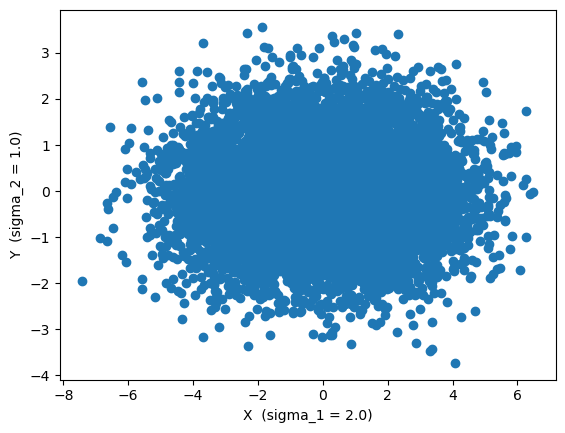

In [117]:
plt.scatter(samples_x, samples_y)
plt.xlabel(f"X  (sigma_1 = {sigma_1})")
plt.ylabel(f"Y  (sigma_2 = {sigma_2})")
plt.show()

-6.0
6.0


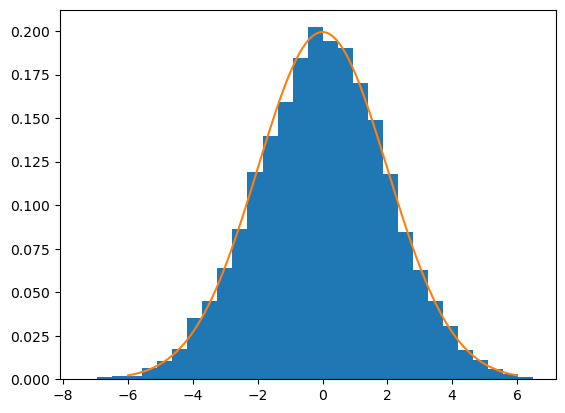

In [118]:
min_x = mu_1 - 3.0 * sigma_1
max_x = mu_1 + 3.0 * sigma_1

print(min_x)
print(max_x)

x_range = np.linspace(min_x, max_x, 1000)

norm_x = stats.norm.pdf(x_range, mu_1, sigma_1)

plt.hist(samples_x, bins=30, density=True)
plt.plot(x_range, norm_x)
plt.show()

-3.0
3.0


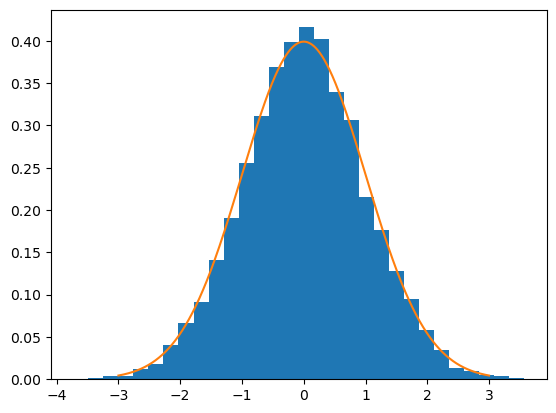

In [119]:
min_y = mu_2 - 3.0 * sigma_2
max_y = mu_2 + 3.0 * sigma_2

print(min_y)
print(max_y)

y_range = np.linspace(min_y, max_y, 1000)

norm_y = stats.norm.pdf(y_range, mu_2, sigma_2)

plt.hist(samples_y, bins=30, density=True)
plt.plot(y_range, norm_y)
plt.show()

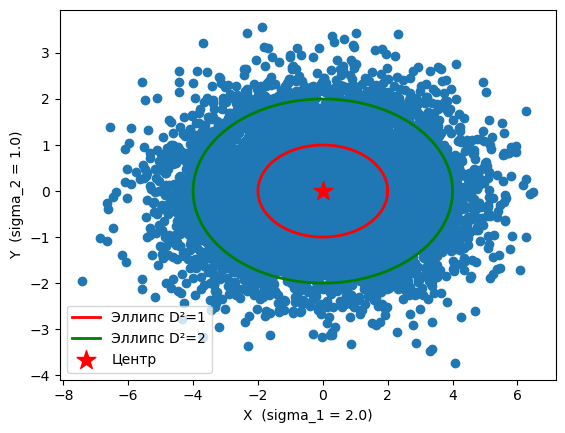

In [120]:
phi_min = 0.0
phi_max = 2 * math.pi

phi_values = np.linspace(phi_min, phi_max, 1000)
x_el_vals_d_1 = mu_1 + sigma_1 * np.cos(phi_values)
y_el_vals_d_1 = mu_2 + sigma_2 * np.sin(phi_values)

x_el_vals_d_2 = mu_1 + 2 * sigma_1 * np.cos(phi_values)
y_el_vals_d_2 = mu_2 + 2 * sigma_2 * np.sin(phi_values)

plt.scatter(samples_x, samples_y)
plt.plot(x_el_vals_d_1, y_el_vals_d_1, 'r-', linewidth=2, label='Эллипс D²=1')
plt.plot(x_el_vals_d_2, y_el_vals_d_2, 'g-', linewidth=2, label='Эллипс D²=2')
plt.scatter(mu_1, mu_2, color='red', s=200, marker='*', label='Центр')
plt.xlabel(f"X  (sigma_1 = {sigma_1})")
plt.ylabel(f"Y  (sigma_2 = {sigma_2})")
plt.legend()
plt.show()

In [121]:
d2_values = {
    '50%': stats.chi2.ppf(0.5, df=2),
    '90%': stats.chi2.ppf(0.9, df=2),
    '95%': stats.chi2.ppf(0.95, df=2)
}

print(d2_values)

{'50%': np.float64(1.386294361119891), '90%': np.float64(4.605170185988092), '95%': np.float64(5.991464547107979)}


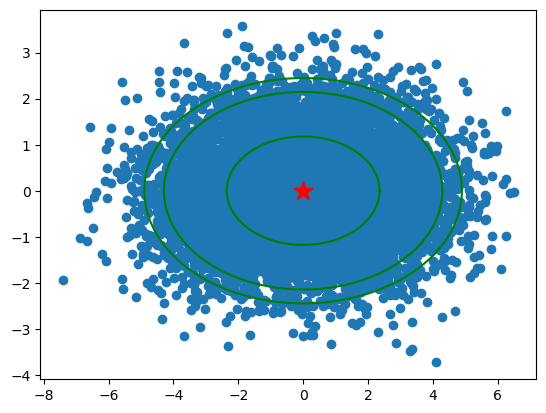

In [122]:

for key in d2_values:
    x_el_vals = mu_1 + sigma_1 * np.cos(phi_values) * math.sqrt(d2_values[key])
    y_el_vals = mu_2 + sigma_2 * np.sin(phi_values) * math.sqrt(d2_values[key])

    plt.plot(x_el_vals, y_el_vals, color='green')

plt.scatter(samples_x, samples_y)
plt.scatter(mu_1, mu_2, color='red', s=200, marker='*', label='Центр')
plt.show()

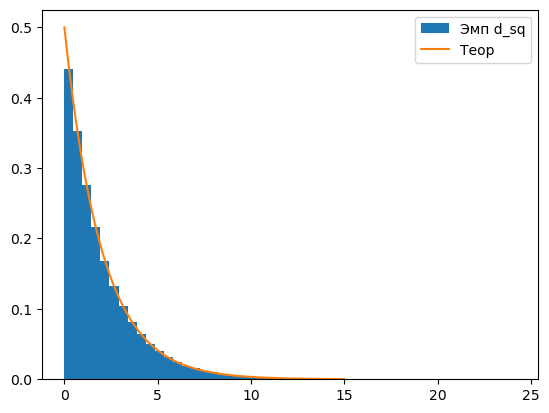

Mean = 1.9963195753326541
Var = 3.9862486271601107


In [123]:
x_samples = rng.normal(mu_1, sigma_1, size=100000)
y_samples = rng.normal(mu_2, sigma_2, size=100000)

d_squared = (x_samples / sigma_1)**2 + (y_samples / sigma_2)**2

x = np.linspace(0, 15, 200)

plt.hist(d_squared, bins=50, density=True, label='Эмп d_sq')
plt.plot(x, stats.chi2.pdf(x, df=2), label='Теор')
plt.legend()
plt.show()

mean = np.mean(d_squared)
var = np.var(d_squared)

print(f"Mean = {mean}") # must be ~ n
print(f"Var = {var}") # must be ~ 2n